# BMesonsML — XGBoost emulator of the SMEFT19 likelihood (rotBIII / Scenario III)

This notebook builds a fast **XGBoost surrogate** of the SMEFT19 global-fit
log-likelihood in the rotBIII (Scenario III) direction — the 3D space of Wilson
coefficients `(C1, C3, βq)` — and uses it to reproduce several figures of the
2025 *b → s* global-fit paper at a tiny fraction of the cost of evaluating
SMEFT19 directly.

**Pipeline:**
1. **Dataset** (§1): Sobol global coverage + a covariance-based cloud around the
   best fit + three 2D plane grids, each point evaluated with SMEFT19 and cached
   on disk. Regenerated only if missing or `FORCE_REBUILD=True`.
2. **Preprocessing** (§2): filter by likelihood, EDA, and an 84/16 train/val
   split (no SMOTE — see §2 for why).
3. **Training** (§3): XGBoost with early stopping + learning curve.
4. **SHAP** (§4): beeswarm, bar, waterfall and dependence plots.
5. **Prediction** (§5): wrapper with an exponential penalty outside the physical
   domain.
6. **Paper figures** (§6–§8): Fig 7 (χ² validation + Monte-Carlo Δχ²
   distribution), Figs 10–11 (Pearson correlation matrices via the RGE to the
   WET + flavio), and the ML speed-up benchmark (Fig 8).

## Setup (run first)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import time, csv, multiprocessing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from pathlib import Path
from scipy.stats.qmc import LatinHypercube, scale
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBRegressor, callback as xgb_cb

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size']   = 12
plt.rcParams['text.usetex'] = False  # use mathtext, not LaTeX

# Paths
ROOT     = Path('..')
DATA_DIR = ROOT / 'data'
OUT_DIR  = ROOT / 'outputs'

DATASET_FILE = DATA_DIR / 'combined_rotBIII_2025.dat'
BESTFIT_FILE = DATA_DIR / 'rotBIII_2025.yaml'
MODEL_OUT    = OUT_DIR  / 'xgboost_scIII.json'
FIGS_DIR     = OUT_DIR  / 'figures'
FIGS_DIR.mkdir(parents=True, exist_ok=True)

# Flags
FORCE_REBUILD  = False
FORCE_RETRAIN  = False
BEST_PARAMS_FILE = OUT_DIR / 'best_params_rotBIII.json'

# Dataset config (generation lives in scripts/regenerate_dataset.py)
N_RANDOM    = 3_000
GRID_SIZE   = 40     # each 2D plane grid is GRID_SIZE x GRID_SIZE
N_FOCUS     = 1_000
FOCUS_SIGMA = 2.0
SEED        = 42

# CPU parallelism (SMEFT19 is CPU-only)
N_WORKERS_OVERRIDE = None   # set an int (e.g. 16) to cap; None = all cores
N_WORKERS = N_WORKERS_OVERRIDE or max(1, multiprocessing.cpu_count() - 1)

# XGBoost device
def _detect_xgb_device():
    """Return 'cuda' if XGBoost can use the GPU here, else 'cpu'."""
    try:
        import xgboost as xgb
        dm = xgb.DMatrix(np.zeros((10, 3)), label=np.zeros(10))
        xgb.train({'device': 'cuda', 'tree_method': 'hist'}, dm,
                  num_boost_round=1, verbose_eval=False)
        return 'cuda'
    except Exception:
        return 'cpu'

# The CUDA build here trains poorly (R2~0.5); CPU is correct and fast
XGB_DEVICE = 'cpu'

# Physical domain
C1_RANGE  = (-0.30,  0.00)
C3_RANGE  = (-0.30,  0.00)
BQ_RANGE  = ( 0.00,  3.20)
LH_MIN    = -50.0
PENALTY_K = 50.0
N_DOF     = 3   # free parameters: C1, C3, bq

print(f'Dataset: {DATASET_FILE}')
print(f'Outputs: {OUT_DIR}')
print(f'Points : {N_RANDOM} random + 3×{GRID_SIZE}²={3*GRID_SIZE**2} grid = {N_RANDOM+3*GRID_SIZE**2} total')
print(f'Workers: {N_WORKERS} CPUs  |  XGBoost device: {XGB_DEVICE}')

Dataset: ../data/combined_rotBIII_2025.dat
Outputs: ../outputs
Points : 3000 random + 3×40²=4800 grid = 7800 total
Workers: 23 CPUs  |  XGBoost device: cpu


## 1. Dataset — generation or load

The dataset `(C1, C3, βq, logL)` is produced by `scripts/regenerate_dataset.py`
(after `scripts/refit_bestfit.py` writes the best fit to `rotBIII_2025.yaml`).
Each point's log-likelihood is the SMEFT19 global fit evaluated with the **2025
measurements**. It combines three complementary samplings:

- **Sobol global** (`N_SOBOL ≈ 4096`): low-discrepancy quasi-random coverage of
  the full physical cube `[C1, C3, βq]` — captures the overall likelihood shape.
- **Covariance-based cloud** (`N_LOCAL ≈ 5000`): Gaussian samples drawn with the
  fit covariance Σ around the best fit, as a two-scale mix (tight core + broad
  shoulder). Because it follows the actual likelihood ellipsoid it automatically
  densifies the narrow `C1` ridge **without** a hand-tuned grid.
- **Three 2D plane grids** (`GRID×GRID`, here 40×40, third parameter fixed at the
  best fit): kept only so §8 can draw the "real SMEFT19 vs emulator" 2D maps.

That is ≈ 13.8k points in total. The best fit (and its covariance Σ) come from
`SMEFT19.ellipse.minimum`, cached in `data/rotBIII_2025.yaml`. Everything is
cached on disk: set `FORCE_REBUILD=True` to recompute from scratch.

> The cells below (re)generate or load the dataset and report how many points are
> valid (`likelihood > LH_MIN`). The old hand-tuned dense `C1` grid is no longer
> needed — the covariance cloud already resolves the `C1` ridge.

In [2]:
# (Re)build the best-fit + dataset with the 2025 measurements, or load the cache.
# Heavy logic lives in scripts/. Set FORCE_REBUILD=True to redo it.
if FORCE_REBUILD or not BESTFIT_FILE.exists() or not DATASET_FILE.exists():
    import sys
    sys.path.insert(0, str((ROOT / 'scripts').resolve()))
    from setup_likelihood import setup_global_likelihood
    from refit_bestfit import refit_bestfit
    from regenerate_dataset import regenerate
    setup_global_likelihood()                            # build the likelihood once
    if FORCE_REBUILD or not BESTFIT_FILE.exists():
        refit_bestfit(BESTFIT_FILE, setup=False)         # -> data/rotBIII_2025.yaml
    regenerate(DATASET_FILE, BESTFIT_FILE, setup=False)  # -> data/combined_rotBIII_2025.dat
else:
    print('Loading cached dataset + best-fit')

df_raw = pd.read_csv(DATASET_FILE, names=['C1', 'C3', 'bq', 'likelihood'])
n_valid = (df_raw['likelihood'] > LH_MIN).sum()
print(f'Total points: {len(df_raw)}  |  valid (lh > {LH_MIN}): {n_valid}')
df_raw.describe()

# SMEFT19 forces text.usetex=True on import; revert so figures use mathtext (no LaTeX needed)
plt.rcParams['text.usetex'] = False

Loading cached dataset + best-fit
Total points: 13896  |  valid (lh > -50.0): 11634


In [3]:
# The covariance-based sampling resolves the narrow C1 ridge, so no extra dense grid is needed.
n_valid = (df_raw['likelihood'] > LH_MIN).sum()
print(f'Dataset: {len(df_raw)} pts  |  valid: {n_valid}')

Dataset: 13896 pts  |  valid: 11634


## 2. Preprocessing

Keep only physical points (`likelihood > LH_MIN`), run a quick EDA (2D scatter of
the three coefficient pairs colored by logL), and make an **84/16 train/validation
split**.

**No SMOTE.** Oversampling was tried and removed: SMOTE interpolates the features
of medium-likelihood points into regions where the true likelihood is high and
then assigns them KNN labels (~17) where the real value is ~30. That creates
contradictory labels near the peak and degrades the emulator exactly where it
matters most. The covariance-based sampling of §1 already densifies the peak, so
no synthetic oversampling is needed.

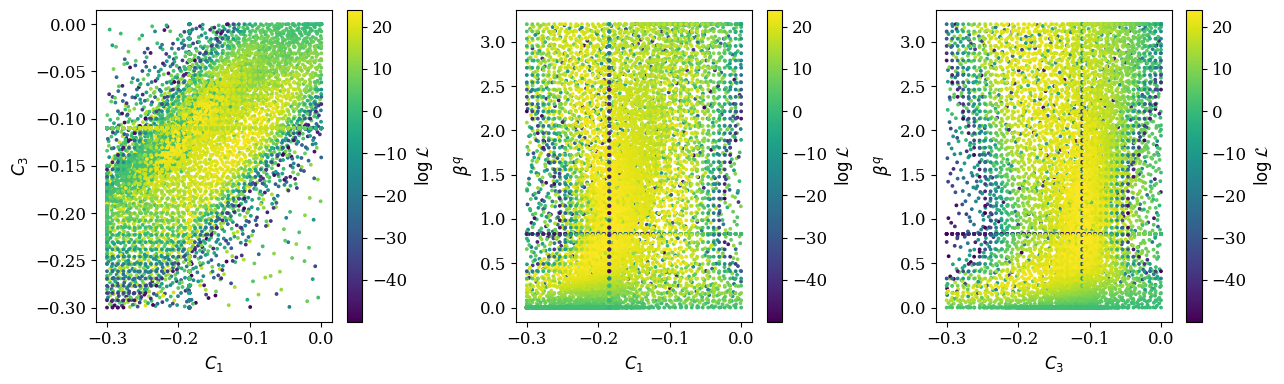

Train: 9772  |  Validation: 1862


In [4]:
df = df_raw[df_raw['likelihood'] > LH_MIN].reset_index(drop=True).copy()

# EDA
pairs   = [('C1', 'C3'), ('C1', 'bq'), ('C3', 'bq')]
xlabels = [r'$C_1$', r'$C_1$', r'$C_3$']
ylabels = [r'$C_3$', r'$\beta^q$', r'$\beta^q$']
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (xc, yc), xl, yl in zip(axes, pairs, xlabels, ylabels):
    sc = ax.scatter(df[xc], df[yc], c=df['likelihood'], cmap='viridis', s=3, rasterized=True)
    plt.colorbar(sc, ax=ax, label=r'$\log\mathcal{L}$')
    ax.set_xlabel(xl); ax.set_ylabel(yl)
fig.tight_layout()
plt.savefig(FIGS_DIR / 'eda_scatter.pdf', bbox_inches='tight')
plt.show()

X, y = df[['C1', 'C3', 'bq']], df['likelihood']

# 84/16 train/validation split
Xtr, Xva, ytr, yva = train_test_split(X, y, test_size=0.16, random_state=SEED)

# No SMOTE: it assigns KNN labels (~17) where the true likelihood is high (~30),
# creating contradictory labels near the peak and degrading the model there.
Xtr_res, ytr_res = Xtr, ytr

print(f'Train: {len(Xtr)}  |  Validation: {len(Xva)}')

## 3. XGBoost training

Gradient-boosted trees regressing `logL` on `(C1, C3, βq)`. The hyperparameters
are the ones validated in the original notebook (`learning_rate=0.03`,
`max_depth=6`, `n_estimators=3000`), trained with **early stopping** (5 rounds on
the validation RMSE) and a learning curve. The fitted model is cached to
`outputs/xgboost_scIII.json`; with `FORCE_RETRAIN=False` it is reloaded instead of
refit.

In [5]:
# XGBoost hyperparameters (validated earlier, RMSE=2.1)
best_xgb_params = dict(
    learning_rate    = 0.03,
    max_depth        = 6,
    min_child_weight = 1,
    subsample        = 1.0,
    colsample_bytree = 1.0,
    gamma            = 0.0,
    reg_alpha        = 0.0,
    reg_lambda       = 1.0,
)
print('Hyperparameters:')
for k, v in best_xgb_params.items():
    print(f'  {k}: {v}')

Hyperparameters:
  learning_rate: 0.03
  max_depth: 6
  min_child_weight: 1
  subsample: 1.0
  colsample_bytree: 1.0
  gamma: 0.0
  reg_alpha: 0.0
  reg_lambda: 1.0


In [6]:
def _plot_learning_curve(info, title='', show=True, save_path=None):
    er     = info['eval_results']
    metric = info['eval_metric']
    keys   = list(er.keys())
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(er[keys[0]][metric], label=f'Train {metric.upper()}', lw=1.4)
    ax.plot(er[keys[1]][metric], label=f'Validation {metric.upper()}', lw=1.4)
    if info.get('best_iteration') is not None:
        ax.axvline(info['best_iteration'], color='gray', ls='--', alpha=0.6,
                   label=f"best_iter={info['best_iteration']}")
    ax.set_yscale('log'); ax.set_xlabel('Boosting iteration'); ax.set_ylabel(metric.upper())
    ax.grid(True, which='both', ls=':', alpha=0.5); ax.legend()
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f'  saved: {save_path}')
    plt.show() if show else plt.close(fig)


if not FORCE_RETRAIN and MODEL_OUT.exists():
    print(f'Loading cached model: {MODEL_OUT}')
    model = XGBRegressor()
    model.load_model(str(MODEL_OUT))
    r2  = float(model.score(Xva, yva))
    mae = float(np.mean(np.abs(model.predict(Xva) - yva.values)))
    print(f'R2 = {r2:.5f}  |  MAE = {mae:.4f}  |  device = {XGB_DEVICE}')
    info = dict(eval_results=None, eval_metric='rmse', best_iteration=None,
                r2=r2, X_val=Xva)
else:
    _defaults = dict(n_estimators=3000, learning_rate=0.03, max_depth=6)
    _params   = {**_defaults, **(best_xgb_params if 'best_xgb_params' in dir() else {})}

    es    = xgb_cb.EarlyStopping(rounds=5, data_name='validation_1', save_best=True)
    model = XGBRegressor(
        **_params,
        tree_method='hist', device=XGB_DEVICE, eval_metric='rmse',
        random_state=SEED, callbacks=[es],
    )
    model.fit(
        Xtr_res, ytr_res,
        eval_set=[(Xtr_res, ytr_res), (Xva, yva)],
        verbose=False,
    )
    model.save_model(str(MODEL_OUT))

    r2   = float(model.score(Xva, yva))
    mae  = float(np.mean(np.abs(model.predict(Xva) - yva.values)))
    best = int(getattr(model, 'best_iteration', model.n_estimators - 1))
    info = dict(
        eval_results   = model.evals_result(),
        eval_metric    = 'rmse',
        best_iteration = best,
        r2             = r2,
        X_val          = Xva,
    )
    print(f'R2 = {r2:.5f}  |  MAE = {mae:.4f}  |  best_iter = {best}  |  device = {XGB_DEVICE}')
    _plot_learning_curve(
        info,
        save_path=FIGS_DIR / 'learning_curve.pdf',
    )

Loading cached model: ../outputs/xgboost_scIII.json
R2 = 0.97308  |  MAE = 1.1584  |  device = cpu


## 4. SHAP analysis

Three plots (same helpers as CosmoML), computed with `TreeExplainer` on the
trained model:
1. **beeswarm + bar**: global importance of each feature.
2. **waterfall**: additive decomposition for a single sample.
3. **dependence**: effect of each feature, colored by interactions (`color=shap_values`).

In [7]:
# SHAP helpers

def _explain(model, X, n_sample=1000, seed=42):
    """TreeExplainer on the model; check_additivity=False."""
    explainer = shap.TreeExplainer(model)
    X_s = X.sample(n=min(n_sample, len(X)), random_state=seed)
    return explainer(X_s, check_additivity=False), X_s


def shap_summary(model, X, title='', save_dir=None, n_sample=1000, show=True):
    """Beeswarm + bar."""
    shap_v, X_s = _explain(model, X, n_sample=n_sample)
    for kind, fn in [('beeswarm', shap.plots.beeswarm), ('bar', shap.plots.bar)]:
        plt.figure()
        fn(shap_v, show=False)
        plt.tight_layout()
        if save_dir is not None:
            p = Path(save_dir) / f'shap_{kind}.pdf'
            plt.savefig(p, dpi=300, bbox_inches='tight'); print(f'  saved: {p}')
        plt.show() if show else plt.close()
    return shap_v, X_s


def shap_waterfall(shap_values, idx=0, title='', save_path=None, show=True):
    """Waterfall for a single sample."""
    plt.figure()
    shap.plots.waterfall(shap_values[idx], show=False)
    plt.tight_layout()
    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight'); print(f'  saved: {save_path}')
    plt.show() if show else plt.close()


def shap_dependence_all(shap_values, X, save_dir=None, prefix='', show=True):
    """Per-feature dependence scatter, colored by interactions."""
    for col in X.columns:
        plt.figure()
        shap.plots.scatter(shap_values[:, col], color=shap_values, show=False)
        plt.tight_layout()
        if save_dir is not None:
            p = Path(save_dir) / f'{prefix}_shap_{col}.pdf'
            plt.savefig(p, dpi=300, bbox_inches='tight'); print(f'  saved: {p}')
        plt.show() if show else plt.close()

  saved: ../outputs/figures/shap_beeswarm.pdf


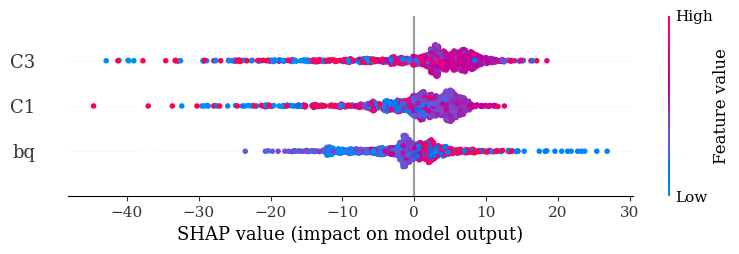

  saved: ../outputs/figures/shap_bar.pdf


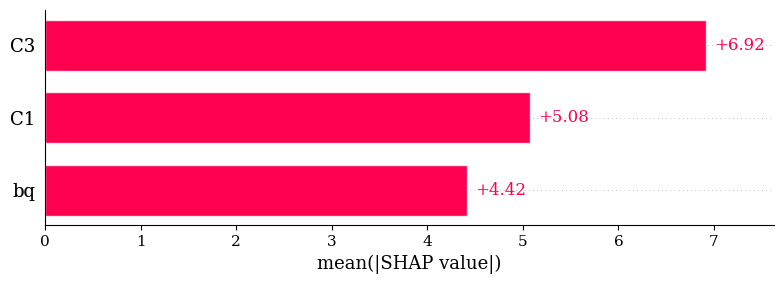

  saved: ../outputs/figures/shap_waterfall.pdf


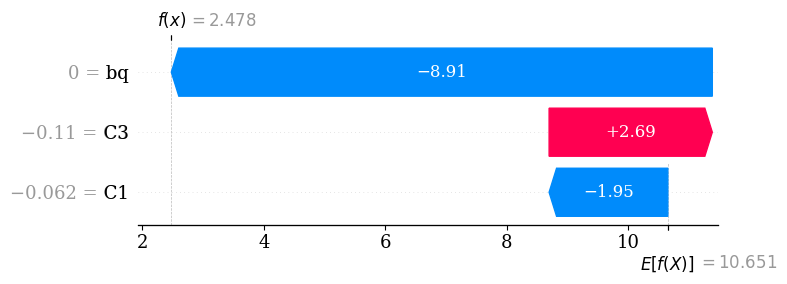

  saved: ../outputs/figures/rotBIII_shap_C1.pdf


<Figure size 640x480 with 0 Axes>

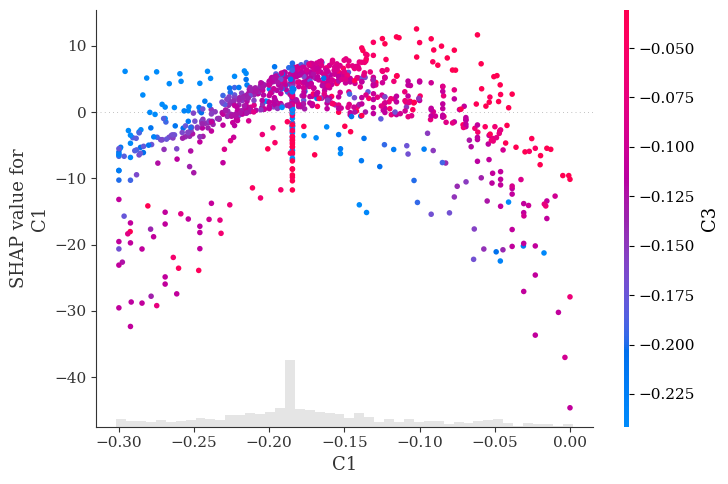

  saved: ../outputs/figures/rotBIII_shap_C3.pdf


<Figure size 640x480 with 0 Axes>

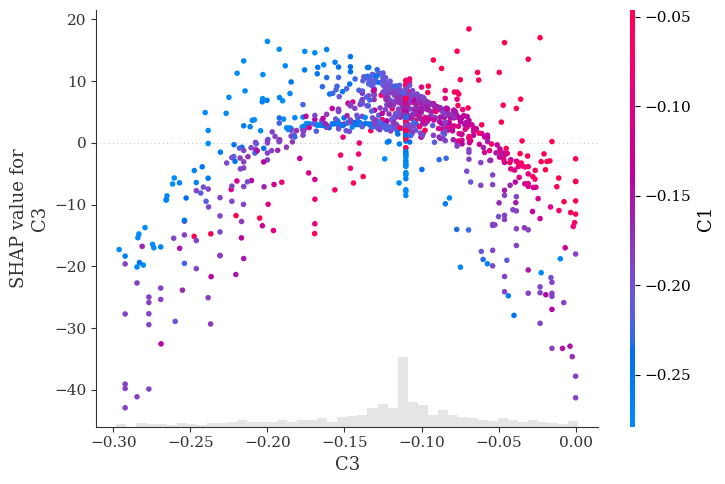

  saved: ../outputs/figures/rotBIII_shap_bq.pdf


<Figure size 640x480 with 0 Axes>

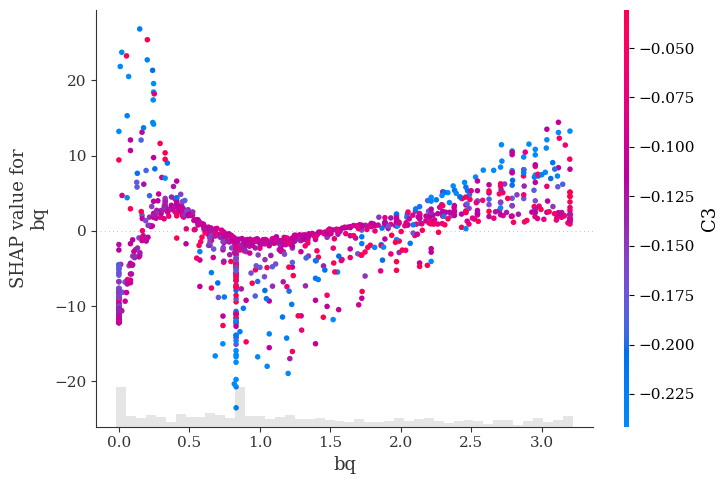

In [8]:
shap_v, X_s = shap_summary(
    model, info['X_val'],
    title='rotBIII · SMEFT19 likelihood',
    save_dir=FIGS_DIR,
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    title='rotBIII · waterfall (sample 0)',
    save_path=FIGS_DIR / 'shap_waterfall.pdf',
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGS_DIR,
    prefix='rotBIII',
    show=True,
)

## 5. Prediction function with boundary penalty

A thin wrapper around the emulator that subtracts an **exponential penalty** when
a query point leaves the training domain, so the surrogate is never trusted in
unphysical extrapolation (the penalty grows like `exp(k·distance)` past each
bound). The demo prints a few in-domain points and one far outside, whose heavy
penalty drives the prediction sharply negative.

In [9]:
def _penalty(v, lo, hi, k=PENALTY_K):
    if v < lo:   return np.exp((lo - v) * k) - 1.0
    elif v > hi: return np.exp((v - hi) * k) - 1.0
    return 0.0


def predict_point(C1, C3, bq):
    """Predict log-likelihood with a penalty outside the physical domain."""
    x   = pd.DataFrame([{'C1': C1, 'C3': C3, 'bq': bq}])
    raw = float(model.predict(x)[0])
    pen = _penalty(C1, *C1_RANGE) + _penalty(C3, *C3_RANGE) + _penalty(bq, *BQ_RANGE)
    return raw - pen


# Demo
test_pts = [(-0.10, -0.10, 1.5), (-0.25, -0.20, 2.0), (0.50, 0.0, 1.5)]
for pt in test_pts:
    print(f'predict_point{pt} = {predict_point(*pt):.4f}')

model.save_model(MODEL_OUT)
print(f'\nModel saved to: {MODEL_OUT}')

predict_point(-0.1, -0.1, 1.5) = 21.8699
predict_point(-0.25, -0.2, 2.0) = 16.8003
predict_point(0.5, 0.0, 1.5) = -72004899336.8550

Model saved to: ../outputs/xgboost_scIII.json


## 6. Figure 7 — χ² validation and Monte-Carlo distribution

Reproduces Figs. 7a and 7b of the paper (Section 4.2):

- **7a**: scatter of predicted vs actual Δχ²_SM on the validation set — measures
  the emulator quality (with the Pearson correlation).
- **7b**: histogram of Δχ² = 2(log L_bf − log L̃) for the Monte-Carlo points vs the
  theoretical χ²(N_DOF) distribution.

**Monte-Carlo algorithm**: a **Metropolis random-walk MCMC** driven entirely by
the emulator. Each proposal is a Gaussian step from the current point with
covariance equal to the fit covariance Σ (Cholesky factor), clipped to the
physical domain, and accepted with the standard Metropolis rule
`log u < log L̃(x′) − log L̃(x)`, `u ~ U(0,1)`. After 3 000 burn-in steps, 15 000
samples are kept. The Δχ² of the chain (relative to the emulator best fit) should
follow χ²(N_DOF = 3). **This single chain is reused in §7** for the correlation
matrices.

YAML best-fit  : C1=-0.18461  C3=-0.11019  bq=0.83135
XGBoost best-fit: C1=-0.18774  C3=-0.11408  bq=0.76413
log_L_bf (XGBoost opt) = 23.9844  |  log_L at YAML bf = 22.8509
1σ (diagonal Σ):  C1=0.0307  C3=0.0212  bq=0.6587

log_L_SM (model) = -2.3230
ΔΔχ²_SM at bf    = 52.61  (best-fit improvement over SM)

Fig 7a — Pearson r = 0.9868  |  MAE = 2.3169


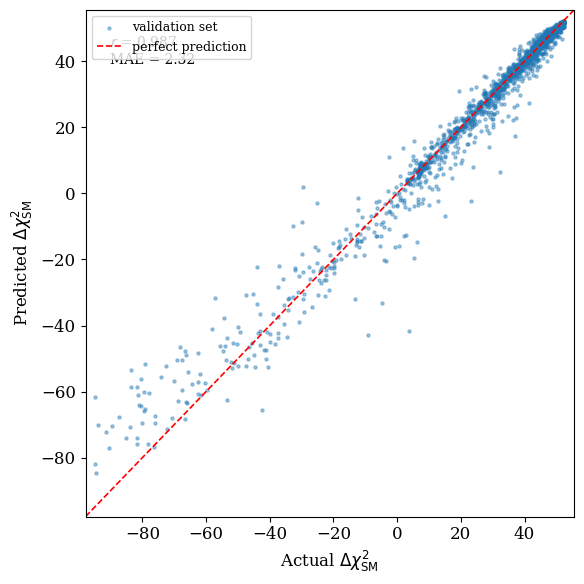

In [10]:
from scipy.stats import pearsonr
import yaml

# Load best-fit and covariance from the YAML
with open(BESTFIT_FILE) as _f:
    _ell = yaml.safe_load(_f)

bf_arr    = np.array(_ell['bf'])
_eig_vals = np.array([_ell['d'][i][i] for i in range(3)])
_V        = np.array(_ell['v'])
Sigma_bf  = _V.T @ np.diag(1.0 / _eig_vals) @ _V
_chol     = np.linalg.cholesky(Sigma_bf)

_sig    = np.sqrt(np.diag(Sigma_bf))
_lo_opt = np.array([C1_RANGE[0], C3_RANGE[0], BQ_RANGE[0]])
_hi_opt = np.array([C1_RANGE[1], C3_RANGE[1], BQ_RANGE[1]])

# ±1σ fine grid to locate the emulator best-fit
_lo_f   = np.maximum(bf_arr - 1.0 * _sig, _lo_opt)
_hi_f   = np.minimum(bf_arr + 1.0 * _sig, _hi_opt)
_nf    = 50
_c1f, _c3f, _bqf = np.meshgrid(np.linspace(_lo_f[0], _hi_f[0], _nf),
                                np.linspace(_lo_f[1], _hi_f[1], _nf),
                                np.linspace(_lo_f[2], _hi_f[2], _nf),
                                indexing='ij')
_fine_df  = pd.DataFrame({'C1': _c1f.ravel(), 'C3': _c3f.ravel(), 'bq': _bqf.ravel()})
_fine_pred = model.predict(_fine_df)
_bi       = int(np.argmax(_fine_pred))
log_L_bf  = float(_fine_pred[_bi])
bf_model  = np.array([float(_fine_df.iloc[_bi]['C1']),
                       float(_fine_df.iloc[_bi]['C3']),
                       float(_fine_df.iloc[_bi]['bq'])])

log_L_bf_yaml = float(model.predict(pd.DataFrame([{'C1': bf_arr[0],
                                                    'C3': bf_arr[1],
                                                    'bq': bf_arr[2]}]))[0])

print(f'YAML best-fit  : C1={bf_arr[0]:.5f}  C3={bf_arr[1]:.5f}  bq={bf_arr[2]:.5f}')
print(f'XGBoost best-fit: C1={bf_model[0]:.5f}  C3={bf_model[1]:.5f}  bq={bf_model[2]:.5f}')
print(f'log_L_bf (XGBoost opt) = {log_L_bf:.4f}  |  log_L at YAML bf = {log_L_bf_yaml:.4f}')
print(f'1σ (diagonal Σ):  C1={np.sqrt(Sigma_bf[0,0]):.4f}  '
      f'C3={np.sqrt(Sigma_bf[1,1]):.4f}  bq={np.sqrt(Sigma_bf[2,2]):.4f}')

log_L_SM = float(model.predict(pd.DataFrame([{'C1': 0., 'C3': 0., 'bq': 0.}]))[0])
print(f'\nlog_L_SM (model) = {log_L_SM:.4f}')
print(f'ΔΔχ²_SM at bf    = {2*(log_L_bf - log_L_SM):.2f}  (best-fit improvement over SM)')

# Fig 7a
y_pred_va  = model.predict(Xva)
dchi2_act  = 2.0 * (yva.values - log_L_SM)
dchi2_pred = 2.0 * (y_pred_va  - log_L_SM)

r_7a, _  = pearsonr(dchi2_act, dchi2_pred)
mae_7a   = np.mean(np.abs(dchi2_act - dchi2_pred))
print(f'\nFig 7a — Pearson r = {r_7a:.4f}  |  MAE = {mae_7a:.4f}')

_lim_lo = min(dchi2_act.min(), dchi2_pred.min()) - 3
_lim_hi = max(dchi2_act.max(), dchi2_pred.max()) + 3

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(dchi2_act, dchi2_pred, s=5, alpha=0.4, rasterized=True,
           label='validation set')
ax.plot([_lim_lo, _lim_hi], [_lim_lo, _lim_hi], 'r--', lw=1.2,
        label='perfect prediction')
ax.set_xlim(_lim_lo, _lim_hi)
ax.set_ylim(_lim_lo, _lim_hi)
ax.set_xlabel(r'Actual $\Delta\chi^2_{\mathrm{SM}}$')
ax.set_ylabel(r'Predicted $\Delta\chi^2_{\mathrm{SM}}$')
ax.text(0.05, 0.95, f'$r$ = {r_7a:.3f}\nMAE = {mae_7a:.2f}',
        transform=ax.transAxes, va='top', fontsize=10)
ax.legend(fontsize=9)
fig.tight_layout()
plt.savefig(FIGS_DIR / 'fig7a_chi2_scatter.pdf', bbox_inches='tight')
plt.show()

LHS points: 11634  |  ESS = 1956 (16.8%)
Importance weighting in 0.04s
MCMC: 3000 burn-in + 15000 samples in 60.8s
Acceptance rate: 31.8%
Mean Dchi2_MC = 3.217  (expected chi2(3) = 3)


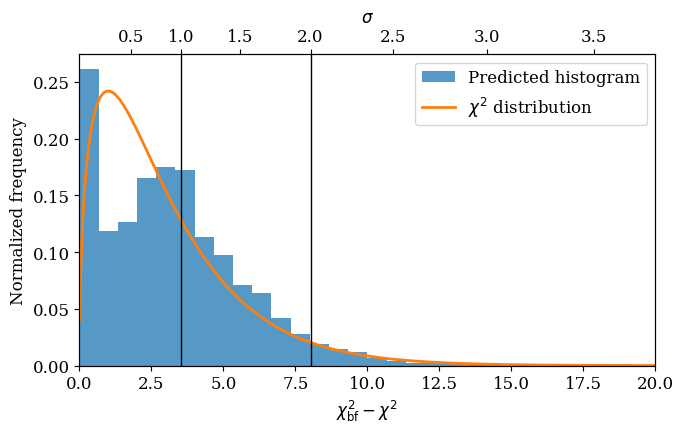

In [11]:
from scipy.stats import chi2 as chi2_dist, norm as norm_dist
import time

# Importance weights
t0_mc = time.time()
X_lhs      = pd.concat([Xtr, Xva], ignore_index=True)
y_true_lhs = np.concatenate([ytr.values, yva.values])
y_xgb_lhs  = model.predict(X_lhs)

L_true_max  = float(y_true_lhs.max())
_log_w      = (y_true_lhs - L_true_max).clip(-500)
w_raw       = np.exp(_log_w)
w_norm      = w_raw / w_raw.sum()
ESS         = float(1.0 / np.sum(w_norm ** 2))
_log_L_ref_lhs = log_L_bf
dchi2_xgb_lhs  = np.maximum(0.0, 2.0 * (_log_L_ref_lhs - y_xgb_lhs))
print(f'LHS points: {len(X_lhs)}  |  ESS = {ESS:.0f} ({100*ESS/len(X_lhs):.1f}%)')
print(f'Importance weighting in {time.time()-t0_mc:.2f}s')

# Metropolis MCMC on the emulator; the chain feeds both Fig 7b and Figs 10/11.
N_MCMC_BURN = 3_000
N_MCMC_KEEP = 15_000

_rng_mc  = np.random.default_rng(SEED + 77)
_chol_s  = np.linalg.cholesky(Sigma_bf)
_lo_dom  = np.array([C1_RANGE[0], C3_RANGE[0], BQ_RANGE[0]])
_hi_dom  = np.array([C1_RANGE[1], C3_RANGE[1], BQ_RANGE[1]])

x_cur = bf_model.copy()
L_cur = float(model.predict(pd.DataFrame([{'C1': x_cur[0], 'C3': x_cur[1], 'bq': x_cur[2]}]))[0])

kept_X  = np.empty((N_MCMC_KEEP, 3))   # (C1, C3, bq)
kept_L  = np.empty(N_MCMC_KEEP)        # log-likelihood
n_kept  = 0
n_total = 0
n_acc   = 0
t0_mc2  = time.time()

# Burn-in
for _ in range(N_MCMC_BURN):
    prop = np.clip(x_cur + _chol_s @ _rng_mc.standard_normal(3), _lo_dom, _hi_dom)
    L_prop = float(model.predict(pd.DataFrame([{'C1': prop[0], 'C3': prop[1], 'bq': prop[2]}]))[0])
    if np.log(_rng_mc.uniform()) < L_prop - L_cur:
        x_cur, L_cur = prop, L_prop

# Sampling
while n_kept < N_MCMC_KEEP:
    prop = np.clip(x_cur + _chol_s @ _rng_mc.standard_normal(3), _lo_dom, _hi_dom)
    L_prop = float(model.predict(pd.DataFrame([{'C1': prop[0], 'C3': prop[1], 'bq': prop[2]}]))[0])
    n_total += 1
    if np.log(_rng_mc.uniform()) < L_prop - L_cur:
        x_cur, L_cur = prop, L_prop
        n_acc += 1
    kept_X[n_kept] = x_cur
    kept_L[n_kept] = L_cur
    n_kept += 1

acc_rate   = n_acc / n_total * 100
dchi2_mc   = np.maximum(0.0, 2.0 * (log_L_bf - kept_L))
mean_dchi2 = float(np.mean(dchi2_mc))
print(f'MCMC: {N_MCMC_BURN} burn-in + {N_MCMC_KEEP} samples in {time.time()-t0_mc2:.1f}s')
print(f'Acceptance rate: {acc_rate:.1f}%')
print(f'Mean Dchi2_MC = {mean_dchi2:.3f}  (expected chi2({N_DOF}) = {N_DOF})')

# Fig 7b
x_max = 20.0
xs    = np.linspace(0.01, x_max, 500)
bins  = np.linspace(0.0, x_max, 31)

_sigma_vals = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5]
_dchi2_top  = [chi2_dist.ppf(norm_dist.cdf(s) - norm_dist.cdf(-s), df=N_DOF)
               for s in _sigma_vals]
_top_ticks  = [(s, d) for s, d in zip(_sigma_vals, _dchi2_top) if d <= x_max]

_vline_1s = chi2_dist.ppf(norm_dist.cdf(1.0) - norm_dist.cdf(-1.0), df=N_DOF)
_vline_2s = chi2_dist.ppf(norm_dist.cdf(2.0) - norm_dist.cdf(-2.0), df=N_DOF)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(dchi2_mc, bins=bins, density=True, alpha=0.75,
        label='Predicted histogram', color='C0')
ax.plot(xs, chi2_dist.pdf(xs, df=N_DOF), lw=2.0, color='C1',
        label=rf'$\chi^2$ distribution')
ax.axvline(_vline_1s, color='k', lw=1.0)
ax.axvline(_vline_2s, color='k', lw=1.0)
ax.set_xlim(0, x_max)
ax.set_xlabel(r'$\chi^2_{\mathrm{bf}} - \chi^2$')
ax.set_ylabel('Normalized frequency')
ax.legend()

ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks([d for _, d in _top_ticks])
ax2.set_xticklabels([f'{s:.1f}' for s, _ in _top_ticks])
ax2.set_xlabel(r'$\sigma$')

fig.tight_layout()
plt.savefig(FIGS_DIR / 'fig7b_chi2_histogram.pdf', bbox_inches='tight')
plt.show()

## 7. Figures 10 and 11 — Pearson correlation matrices

Reproduces Section 4.3 of the paper:

- **Fig 10**: correlations among WET Wilson coefficients (C₉, C₁₀, CVL, Cν per
  lepton generation + Δχ²_SM).
- **Fig 11**: correlations among selected flavor observables (R_K*, R_D(*),
  BR(Bs→μμ), BR(B⁺→Kνν), …).

**Procedure** (as in the paper):
1. **Reuse** the 15 000-sample MCMC chain from §6 (Fig 7b) — `kept_X`/`kept_L`, so
   no second MCMC is run.
2. For each point, run the SMEFT → WET RGE down to µ = m_b = 4.8 GeV with `wilson`
   (`match_run`).
3. Compute the observables with `flavio`.
4. Compute the Pearson correlation coefficients and plot the matrices (only
   coefficients/observables with non-negligible variance are kept).

> **Requires** SMEFT19, wilson and flavio installed (the earlier cells do not need
> them).

In [12]:
# Correlation-matrix sample: reuse the Fig 7b MCMC chain (kept_X, kept_L).
N_MC_CORR = N_MCMC_KEEP

mc_df = pd.DataFrame({
    'C1':         kept_X[:, 0],
    'C3':         kept_X[:, 1],
    'bq':         kept_X[:, 2],
    'log_L_pred': kept_L,
    'delta_chi2': np.maximum(0.0, 2.0 * (log_L_bf - kept_L)),
})
print(f'MC sample: {N_MC_CORR} MCMC points (shared with Fig 7b)')
mc_df[['C1', 'C3', 'bq', 'delta_chi2']].describe()

MC sample: 15000 MCMC points (shared with Fig 7b)


,C1,C3,bq,delta_chi2
count,15000.000000,15000.000000,15000.000000,15000.000000
mean,-0.180593,-0.140146,1.872691,3.217303
std,0.054710,0.027024,0.954929,2.487414
min,-0.300000,-0.245884,0.172444,0.000000
25%,-0.235579,-0.157474,0.965745,1.309597
50%,-0.176669,-0.140376,1.941793,2.959206
75%,-0.134686,-0.121476,2.732937,4.606926
max,-0.043161,-0.057748,3.200000,19.303719


Non-zero WET coefficients at the best-fit (374 total):
  C10_bdee                                      = -0.000002+0.000000j
  C10_bdmumu                                    = -0.000002+0.000000j
  C10_bdtautau                                  = -0.083569+0.000048j
  C10_bsee                                      = -0.002379-0.000045j
  C10_bsmumu                                    = -0.002379-0.000045j
  C10_bstautau                                  = -82.880636-1.551276j
  C10_cuee                                      = -0.025959-0.078643j
  C10_cumumu                                    = -0.025959-0.078643j
  C10_cutautau                                  = +325.163609+985.087074j
  C10_sdee                                      = +0.000035-0.000001j
  C10_sdmumu                                    = +0.000035-0.000001j
  C10_sdtautau                                  = +1.686328-0.032531j
  C10p_bstautau                                 = -0.000006-0.000000j
  C10p_cutautau               

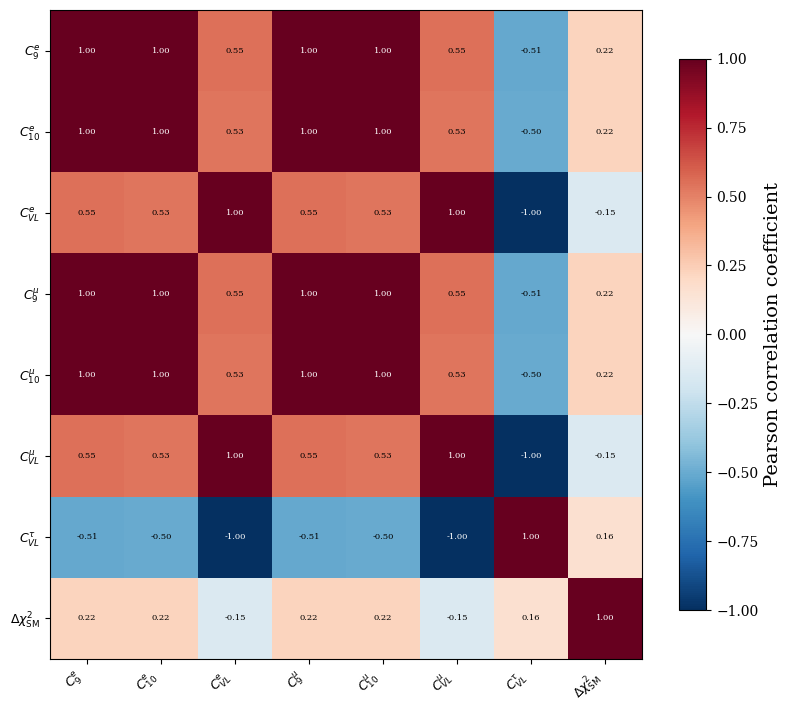

In [13]:
import SMEFT19
plt.rcParams['text.usetex'] = False  # SMEFT19 sets usetex=True on import

# Initialize SMEFT19 and auto-discover the non-zero WET coefficients
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    SMEFT19.SMEFTglob.gl.make_measurement()

_w_bf  = SMEFT19.scenarios.massrotation([bf_arr[0], bf_arr[1], 0.0, 0.0, 0.0, bf_arr[2]])
_wc_bf = _w_bf.match_run(4.8, 'WET', 'flavio')
_wcd_bf = _wc_bf.dict

WET_COLS = sorted(k for k, v in _wcd_bf.items() if abs(v) > 1e-8)
print(f'Non-zero WET coefficients at the best-fit ({len(WET_COLS)} total):')
for k in WET_COLS:
    print(f'  {k:45s} = {_wcd_bf[k]:+.6f}')

# Semileptonic coefficients shown in Fig 10
_WET_LABEL_MAP = {
    'C9_bsee':              r'$C_9^e$',
    'C10_bsee':             r'$C_{10}^e$',
    'CVL_bcenue':           r'$C_{VL}^e$',
    'Cnu_bsnuenue':         r'$C_\nu^e$',
    'C9_bsmumu':            r'$C_9^\mu$',
    'C10_bsmumu':           r'$C_{10}^\mu$',
    'CVL_bcmunumu':         r'$C_{VL}^\mu$',
    'Cnu_bsnumunumu':       r'$C_\nu^\mu$',
    'CVL_bctaunutau':       r'$C_{VL}^\tau$',
    'Cnu_bsnutaunutau':     r'$C_\nu^\tau$',
}

args_wet = [
    (row['C1'], row['C3'], row['bq'], row['delta_chi2'])
    for _, row in mc_df.iterrows()
]

# Serial: match_run is fast matrix algebra (~ms/point) once SMEFT19 is initialized.
print(f'\nComputing WET coefficients for {N_MC_CORR} points (serial)...')
t0w = time.time()
_wet_raw = []
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for i, (C1, C3, bq, dchi2) in enumerate(args_wet):
        try:
            w  = SMEFT19.scenarios.massrotation([C1, C3, 0.0, 0.0, 0.0, bq])
            wc = w.match_run(4.8, 'WET', 'flavio')
            _wet_raw.append({'delta_chi2': dchi2, **wc.dict})
        except Exception:
            _wet_raw.append(None)
        if (i + 1) % 3000 == 0:
            print(f'  {i+1}/{N_MC_CORR}  ({time.time()-t0w:.0f}s)')
print(f'Done in {time.time()-t0w:.0f}s')

wet_df = pd.DataFrame([r for r in _wet_raw if r is not None])
print(f'Valid rows: {len(wet_df)}/{N_MC_CORR}')

# Keep the Fig 10 coefficients with non-zero variance in the sample
_wet_plot_cols = [
    c for c in _WET_LABEL_MAP
    if c in wet_df.columns and wet_df[c].std() > 1e-12
] + ['delta_chi2']
_wet_labels = (
    [_WET_LABEL_MAP[c] for c in _wet_plot_cols[:-1]]
    + [r'$\Delta\chi^2_{\mathrm{SM}}$']
)
print(f'WET coefficients with non-zero variance: {_wet_plot_cols[:-1]}')

_corr10 = wet_df[_wet_plot_cols].corr(method='pearson')
_n10    = len(_wet_plot_cols)

fig, ax = plt.subplots(figsize=(_n10 * 0.9 + 1, _n10 * 0.85 + 0.5))
im = ax.imshow(_corr10.values, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
plt.colorbar(im, ax=ax, label='Pearson correlation coefficient', shrink=0.85)

ax.set_xticks(range(_n10)); ax.set_yticks(range(_n10))
ax.set_xticklabels(_wet_labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(_wet_labels, fontsize=9)

for i in range(_n10):
    for j in range(_n10):
        val   = _corr10.iloc[i, j]
        if np.isnan(val): continue
        color = 'white' if abs(val) > 0.65 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=6, color=color)

fig.tight_layout()
plt.savefig(FIGS_DIR / 'fig10_wet_correlations.pdf', bbox_inches='tight')
plt.show()

Computing flavio observables for 15000 points (serial)...
  1000/15000  (45s)
  2000/15000  (91s)
  3000/15000  (136s)
  4000/15000  (182s)
  5000/15000  (227s)
  6000/15000  (272s)
  7000/15000  (318s)
  8000/15000  (363s)
  9000/15000  (409s)
  10000/15000  (454s)
  11000/15000  (499s)
  12000/15000  (545s)
  13000/15000  (590s)
  14000/15000  (636s)
  15000/15000  (681s)
Done in 681s
Valid rows: 15000/15000

Relative variance of each observable:
  BR(B+->Knunu)                   39.302%  ✓
  BR(B0->K*0nunu)                    nan%  ✗ excluded (<1%)
  BR(K+->pinunu)                   1.679%  ✓
  Rtaul(B->D*lnu)                  2.335%  ✓
  Rtaul(B->Dlnu)                   2.335%  ✓
  Rtaumu(Bc->J/psilnu)             2.335%  ✓
  BR(Bs->mumu)                     0.018%  ✗ excluded (<1%)
  BR(B0->mumu)                     0.000%  ✗ excluded (<1%)
  <Rmue>(B0->K*ll)                 0.007%  ✗ excluded (<1%)
  <Rmue>(B+->Kll)                  0.003%  ✗ excluded (<1%)
  BR(tau->mununu)     

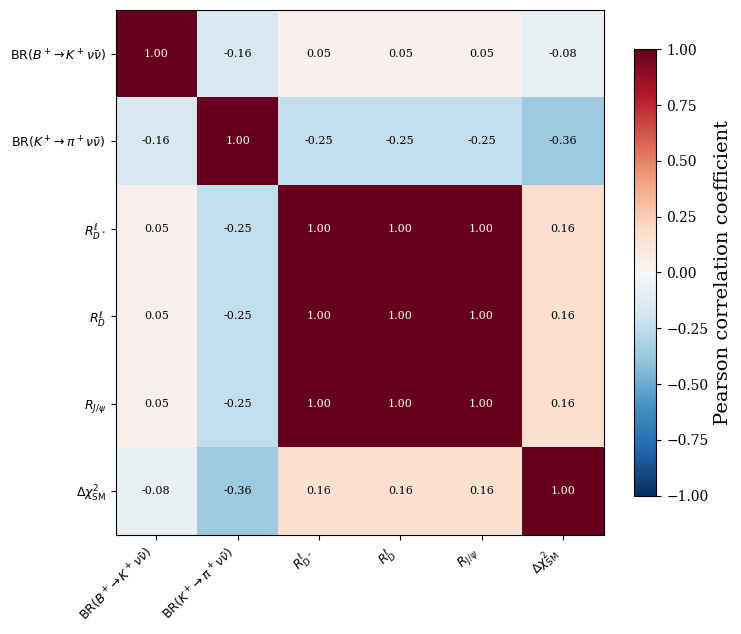

In [14]:
import flavio
import wilson as _wilson
import gc
plt.rcParams['text.usetex'] = False

# Observables for Scenario III. R_D* and BR(B+->K+nunu) decorrelate when C1 != C3.
OBS_DEF = [
    # b->snunu (depends on C1-C3 in Scenario III)
    ('BR(B+->Knunu)',         {},                             r'$\mathrm{BR}(B^+\!\to K^+\nu\bar\nu)$'),
    ('BR(B0->K*0nunu)',       {},                             r'$\mathrm{BR}(B^0\!\to K^{*0}\nu\bar\nu)$'),
    ('BR(K+->pinunu)',        {},                             r'$\mathrm{BR}(K^+\!\to\pi^+\nu\bar\nu)$'),
    # b->ctaunu (depends on C3)
    ('Rtaul(B->D*lnu)',       {},                             r'$R_{D^*}^\ell$'),
    ('Rtaul(B->Dlnu)',        {},                             r'$R_D^\ell$'),
    ('Rtaumu(Bc->J/psilnu)',  {},                             r'$R_{J/\psi}$'),
    # b->sll loop (depends on C1+C3 via C9^mu LFU)
    ('BR(Bs->mumu)',          {},                             r'$\mathrm{BR}(B_s\!\to\mu^+\mu^-)$'),
    ('BR(B0->mumu)',          {},                             r'$\mathrm{BR}(B^0\!\to\mu^+\mu^-)$'),
    ('<Rmue>(B0->K*ll)',      {'q2min': 1.1, 'q2max': 6.0},  r'$R_{K^*}^{[1.1,6]}$'),
    ('<Rmue>(B+->Kll)',       {'q2min': 1.1, 'q2max': 6.0},  r'$R_K^{[1.1,6]}$'),
    # leptonic tau (SM reference - should be constant)
    ('BR(tau->mununu)',       {},                             r'$\mathrm{BR}(\tau\!\to\mu\nu\nu)$'),
]

_wet_coeff_cols = [c for c in wet_df.columns if c != 'delta_chi2']

print(f'Computing flavio observables for {len(wet_df)} points (serial)...')
t0o = time.time()
_obs_raw = []

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for i, (_, row) in enumerate(wet_df.iterrows()):
        try:
            wc_dict = {k: float(row[k]) for k in _wet_coeff_cols
                       if pd.notna(row[k]) and abs(float(row[k])) > 1e-15}
            wc = _wilson.Wilson(wc_dict, scale=4.8, eft='WET', basis='flavio')
            result = {'delta_chi2': row['delta_chi2']}
            for obs_name, kwargs, _ in OBS_DEF:
                try:
                    result[obs_name] = float(flavio.np_prediction(obs_name, wc, **kwargs))
                except Exception:
                    result[obs_name] = float('nan')
            _obs_raw.append(result)
        except Exception:
            _obs_raw.append(None)
        if (i + 1) % 100 == 0:
            gc.collect()
        if (i + 1) % 1000 == 0:
            print(f'  {i+1}/{len(wet_df)}  ({time.time()-t0o:.0f}s)')

print(f'Done in {time.time()-t0o:.0f}s')
obs_df = pd.DataFrame([r for r in _obs_raw if r is not None])
print(f'Valid rows: {len(obs_df)}/{len(wet_df)}')

# Variance diagnostic: in Scenario III, R_K* ~ 1 (LFU) and the loop observables
# vary < 1%; keep only observables with real variance.
_obs_all_cols   = [o[0] for o in OBS_DEF if o[0] in obs_df.columns]
_obs_all_labels = {o[0]: o[2] for o in OBS_DEF}

print('\nRelative variance of each observable:')
for col in _obs_all_cols:
    mean_v = obs_df[col].mean()
    std_v  = obs_df[col].std()
    rel    = 100 * std_v / abs(mean_v) if mean_v != 0 else 0
    flag   = '✓' if rel > 1.0 else '✗ excluded (<1%)'
    print(f'  {col:30s}  {rel:6.3f}%  {flag}')

MIN_REL_STD = 1e-3  # 0.1%: include observables with small but real variance
_obs_cols = [
    c for c in _obs_all_cols
    if obs_df[c].std() / abs(obs_df[c].mean()) > MIN_REL_STD
] + ['delta_chi2']
_obs_labels = [_obs_all_labels[c] for c in _obs_cols[:-1]] + [r'$\Delta\chi^2_{\mathrm{SM}}$']
print(f'\nIncluded observables: {_obs_cols[:-1]}')

if len(_obs_cols) < 2:
    print('⚠ Too few observables with enough variance. Check the MCMC.')
else:
    _corr11 = obs_df[_obs_cols].corr(method='pearson')
    _n11    = len(_obs_cols)

    fig, ax = plt.subplots(figsize=(_n11 * 1.1 + 1, _n11 * 1.0 + 0.5))
    im = ax.imshow(_corr11.values, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
    plt.colorbar(im, ax=ax, label='Pearson correlation coefficient', shrink=0.85)

    ax.set_xticks(range(_n11)); ax.set_yticks(range(_n11))
    ax.set_xticklabels(_obs_labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(_obs_labels, fontsize=9)

    for i in range(_n11):
        for j in range(_n11):
            val = _corr11.iloc[i, j]
            if np.isnan(val): continue
            color = 'white' if abs(val) > 0.65 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=8, color=color)

    fig.tight_layout()
    plt.savefig(FIGS_DIR / 'fig11_obs_correlations.pdf', bbox_inches='tight')
    plt.show()

## 8. The ML advantage — likelihood maps and speed benchmark

A direct demonstration of the paper's central argument: **why is the emulator
needed?**

- **2D likelihood maps**: the real SMEFT19 values already exist in the dataset
  (the three 40×40 plane grids). XGBoost reproduces those maps in milliseconds,
  and it also generates dense 200×200 grids (= 40 000 evaluations) that SMEFT19
  would take days to produce.

- **Speed benchmark** (~2–5 min): measures the actual XGBoost vs SMEFT19 wall time,
  computes the speed-up factor, and extrapolates it to the cost of the full
  Monte-Carlo analysis (Sections 6 and 7).

Plane C1-C3: SMEFT19 grid from data | XGBoost 200x200 = 40,000 evals in 78.8 ms
Plane C1-bq: SMEFT19 grid from data | XGBoost 200x200 = 40,000 evals in 78.2 ms
Plane C3-bq: SMEFT19 grid from data | XGBoost 200x200 = 40,000 evals in 77.6 ms


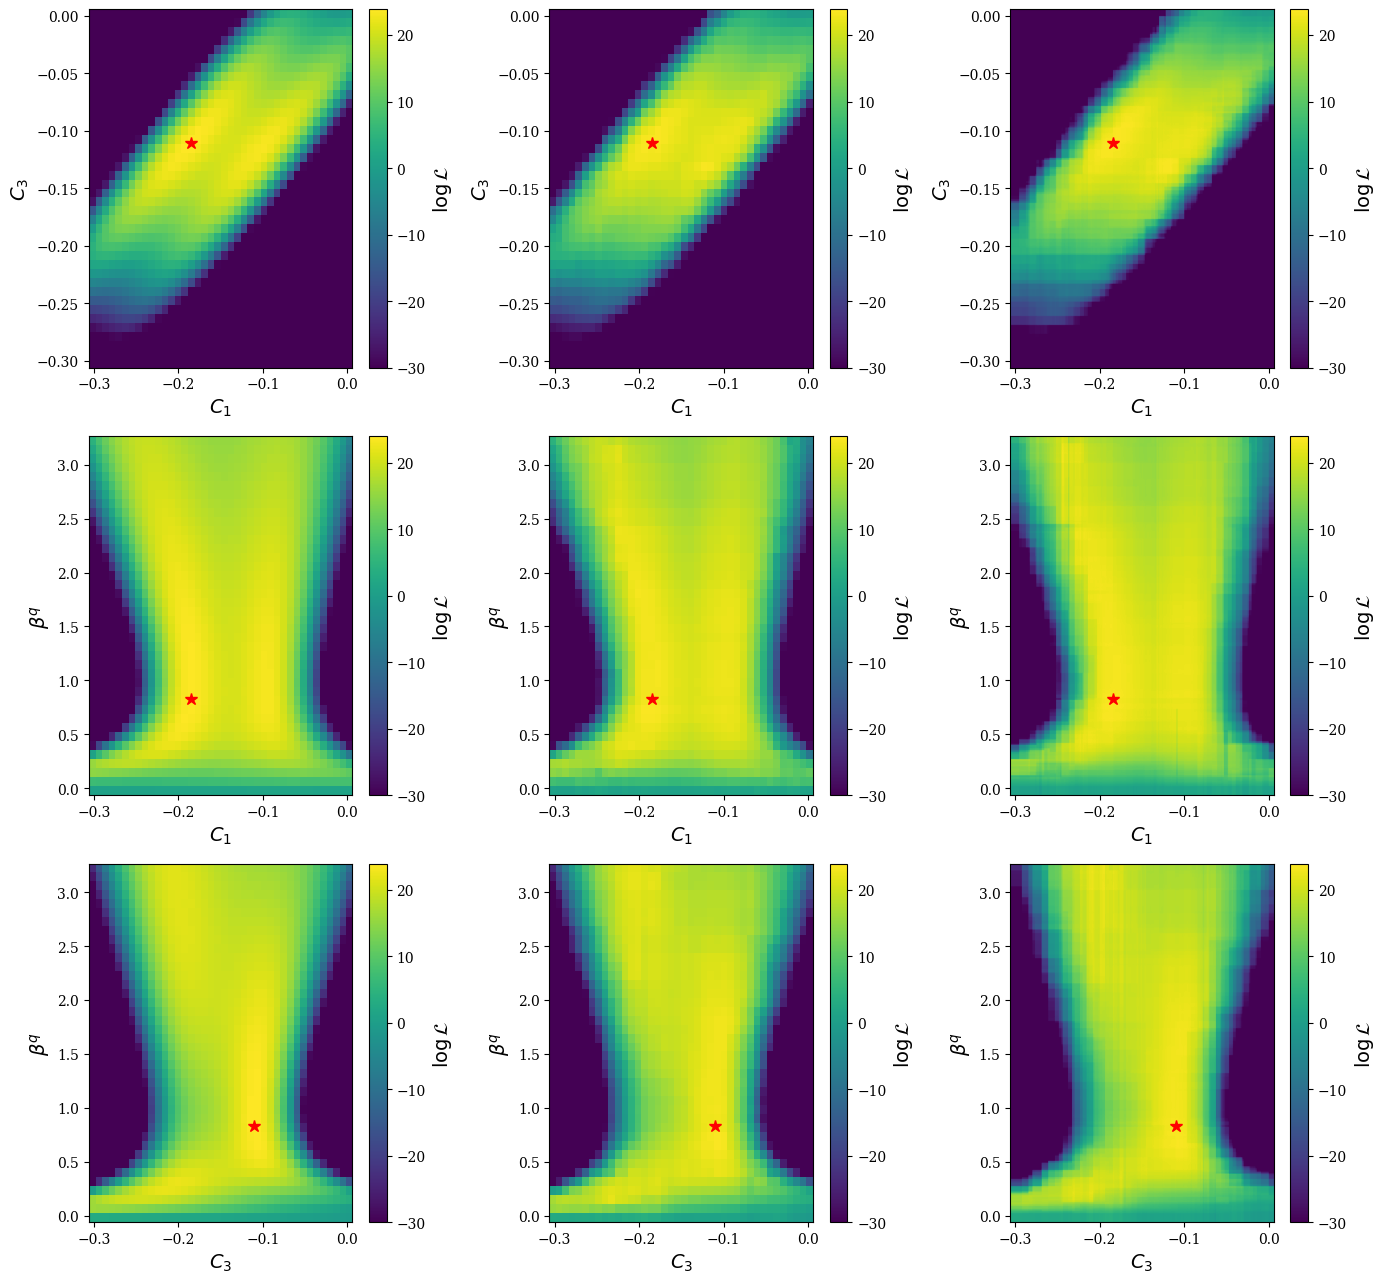

Fig 8a saved.


In [15]:
# Section 8a: 2D likelihood map - real SMEFT19 vs XGBoost emulator
DENSE  = 200
_MARG  = 0.02

def _rng_ext(col):
    """Range with the same margin used for the grid points."""
    lo, hi = {'C1': C1_RANGE, 'C3': C3_RANGE, 'bq': BQ_RANGE}[col]
    m = _MARG * (hi - lo)
    return lo - m, hi + m

# The 3 plane grids are the last 3*GRID_SIZE^2 rows of the dataset
_g2 = GRID_SIZE ** 2
_base = len(df_raw) - 3 * _g2
PLANES = [
    {'cx': 'C1', 'cy': 'C3',  'cz': 'bq', 'vz': bf_arr[2],
     's0': _base,           's1': _base + _g2,
     'xl': r'$C_1$', 'yl': r'$C_3$'},
    {'cx': 'C1', 'cy': 'bq',  'cz': 'C3', 'vz': bf_arr[1],
     's0': _base + _g2,     's1': _base + 2 * _g2,
     'xl': r'$C_1$', 'yl': r'$\beta^q$'},
    {'cx': 'C3', 'cy': 'bq',  'cz': 'C1', 'vz': bf_arr[0],
     's0': _base + 2 * _g2, 's1': _base + 3 * _g2,
     'xl': r'$C_3$', 'yl': r'$\beta^q$'},
]

LH_CLIP  = -30.0
BF_COLS  = ['C1', 'C3', 'bq']

fig, axes = plt.subplots(3, 3, figsize=(14, 13))

for ri, p in enumerate(PLANES):
    cx, cy, cz = p['cx'], p['cy'], p['cz']
    rx, ry     = _rng_ext(cx), _rng_ext(cy)
    ext        = [rx[0], rx[1], ry[0], ry[1]]

    # Real SMEFT19 values from the dataset (GRID_SIZE x GRID_SIZE plane grid)
    grid_sl  = df_raw.iloc[p['s0']:p['s1']]
    # outer loop = cx, inner loop = cy; imshow needs [iy, ix] -> transpose
    lh_smeft = grid_sl['likelihood'].values.clip(LH_CLIP).reshape(GRID_SIZE, GRID_SIZE)

    # XGBoost on the same grid points
    X_sp     = grid_sl[['C1', 'C3', 'bq']].reset_index(drop=True)
    lh_xgb_s = model.predict(X_sp).clip(LH_CLIP).reshape(GRID_SIZE, GRID_SIZE)

    # Dense 200x200 XGBoost grid
    xs_d, ys_d = np.linspace(*rx, DENSE), np.linspace(*ry, DENSE)
    XX, YY     = np.meshgrid(xs_d, ys_d)          # [DENSE, DENSE]; row=y, col=x
    X_dense    = pd.DataFrame({cx: XX.ravel(), cy: YY.ravel(),
                                cz: p['vz']})[BF_COLS]
    t0_dense   = time.perf_counter()
    lh_xgb_d   = model.predict(X_dense).clip(LH_CLIP).reshape(DENSE, DENSE)
    t_dense    = time.perf_counter() - t0_dense
    # meshgrid layout is already correct for imshow without transpose

    # Shared color scale
    vmax = float(np.nanmax(lh_smeft))
    kw   = dict(origin='lower', aspect='auto', extent=ext,
                vmin=LH_CLIP, vmax=vmax, cmap='viridis')

    bfx = bf_arr[BF_COLS.index(cx)]
    bfy = bf_arr[BF_COLS.index(cy)]

    for ci, (arr, do_T) in enumerate([(lh_smeft, True), (lh_xgb_s, True), (lh_xgb_d, False)]):
        ax = axes[ri, ci]
        im = ax.imshow(arr.T if do_T else arr, **kw)
        ax.plot(bfx, bfy, 'r*', ms=9, zorder=5, label='best fit')
        ax.set_xlabel(p['xl']); ax.set_ylabel(p['yl'])
        plt.colorbar(im, ax=ax, label=r'$\log\mathcal{L}$')

    print(f'Plane {cx}-{cy}: SMEFT19 grid from data | '
          f'XGBoost 200x200 = {DENSE**2:,} evals in {t_dense*1000:.1f} ms')

fig.tight_layout()
plt.savefig(FIGS_DIR / 'fig8a_likelihood_maps.pdf', bbox_inches='tight', dpi=150)
plt.show()
print('Fig 8a saved.')

XGBoost:  10,000 evals in 30.1 ms → 3.01 µs / eval
SMEFT19:  30 evals in 787.7s (23 workers) → 603.885 s / eval (serial equiv.)

Speed-up factor: 200,861,847×
Full MC analysis (47,110 proposals, 15,000 accepted):
  XGBoost → 0.1 s
  SMEFT19 → 7903 hours (serial equiv.)


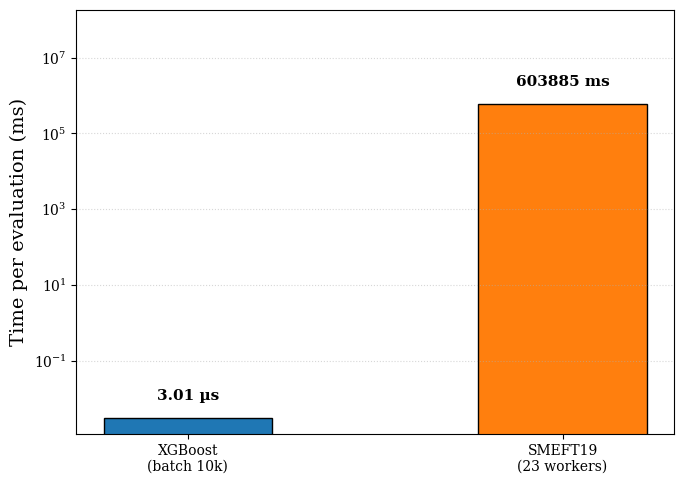


─── Summary ──────────────────────────────
  XGBoost  : 3.01 µs / eval
  SMEFT19  : 603885 ms / eval  (serial equiv.)
  Speedup  : 200,861,847×
  MC (15,000 pts): XGBoost = 0s  |  SMEFT19 ≈ 7903h


In [16]:
# Worker hooks for the SMEFT19 benchmark (import SMEFT19 lazily so loading the
# dataset cache does not trigger building the likelihood).
def _worker_init():
    import sys
    sys.path.insert(0, str((ROOT / 'scripts').resolve()))
    from setup_likelihood import setup_global_likelihood
    setup_global_likelihood(verbose=False)

def _eval_point(row):
    import SMEFT19
    C1, C3, bq = row
    try:
        return max(float(SMEFT19.likelihood_global([C1, C3, 0.0, 0.0, 0.0, bq],
                                                    SMEFT19.scenarios.massrotation)), -200.0)
    except Exception:
        return -200.0


# Section 8b: speed benchmark - XGBoost vs SMEFT19
N_BENCH_XGB   = 10_000   # XGBoost points (batch)
N_BENCH_SMEFT = 30       # SMEFT19 points (extrapolated; more would take too long)

# 1. XGBoost benchmark (batch)
_rng_bm = np.random.default_rng(SEED + 999)
X_bm = pd.DataFrame({
    'C1': _rng_bm.uniform(*C1_RANGE, N_BENCH_XGB),
    'C3': _rng_bm.uniform(*C3_RANGE, N_BENCH_XGB),
    'bq': _rng_bm.uniform(*BQ_RANGE, N_BENCH_XGB),
})
_ = model.predict(X_bm.iloc[:10])  # warm-up

t0_xgb = time.perf_counter()
_ = model.predict(X_bm)
t_xgb  = time.perf_counter() - t0_xgb
xgb_per_eval = t_xgb / N_BENCH_XGB

print(f'XGBoost:  {N_BENCH_XGB:,} evals in {t_xgb*1000:.1f} ms '
      f'→ {xgb_per_eval*1e6:.2f} µs / eval')

# 2. SMEFT19 benchmark (parallel)
pts_smeft = X_bm.iloc[:N_BENCH_SMEFT][['C1', 'C3', 'bq']].values.tolist()

t0_smeft = time.perf_counter()
with multiprocessing.Pool(N_WORKERS, initializer=_worker_init) as pool:
    _ = pool.map(_eval_point, pts_smeft, chunksize=5)
t_smeft      = time.perf_counter() - t0_smeft
smeft_per_eval = t_smeft / N_BENCH_SMEFT * N_WORKERS  # serial-equivalent time

print(f'SMEFT19:  {N_BENCH_SMEFT} evals in {t_smeft:.1f}s '
      f'({N_WORKERS} workers) → {smeft_per_eval:.3f} s / eval (serial equiv.)')

# 3. Speed-up factor and extrapolation to the full MC analysis
speedup = smeft_per_eval / xgb_per_eval

# Total proposals for sections 6+7 (using the acceptance rate from Fig 7b)
_rate_used = acc_rate / 100.0 if 'acc_rate' in dir() else 0.03
N_ACCEPT_TOTAL  = N_MCMC_KEEP  # total MCMC points generated
N_PROPOSE_TOTAL = int(N_ACCEPT_TOTAL / _rate_used)

t_mc_xgb_s   = N_PROPOSE_TOTAL * xgb_per_eval
t_mc_smeft_h = N_PROPOSE_TOTAL * smeft_per_eval / 3600

print(f'\nSpeed-up factor: {speedup:,.0f}×')
print(f'Full MC analysis ({N_PROPOSE_TOTAL:,} proposals, {N_ACCEPT_TOTAL:,} accepted):')
print(f'  XGBoost → {t_mc_xgb_s:.1f} s')
print(f'  SMEFT19 → {t_mc_smeft_h:.0f} hours (serial equiv.)')

# 4. Comparison bar chart (log scale)
labels  = [f'XGBoost\n(batch {N_BENCH_XGB//1000}k)',
           f'SMEFT19\n({N_WORKERS} workers)']
t_ms    = [xgb_per_eval * 1000, smeft_per_eval * 1000]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, t_ms, color=['C0', 'C1'], edgecolor='k', width=0.45)
ax.set_yscale('log')
ax.set_ylabel('Time per evaluation (ms)')
ax.grid(True, axis='y', which='both', ls=':', alpha=0.5)

for bar, val in zip(bars, t_ms):
    lbl = f'{val*1000:.2f} µs' if val < 1 else f'{val:.0f} ms'
    ax.text(bar.get_x() + bar.get_width() / 2,
            val * 2.5, lbl, ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(top=max(t_ms) * 300)
fig.tight_layout()
plt.savefig(FIGS_DIR / 'fig8b_speed_benchmark.pdf', bbox_inches='tight')
plt.show()

print(f'\n─── Summary ──────────────────────────────')
print(f'  XGBoost  : {xgb_per_eval*1e6:.2f} µs / eval')
print(f'  SMEFT19  : {smeft_per_eval*1000:.0f} ms / eval  (serial equiv.)')
print(f'  Speedup  : {speedup:,.0f}×')
print(f'  MC ({N_ACCEPT_TOTAL:,} pts): XGBoost = {t_mc_xgb_s:.0f}s  |  SMEFT19 ≈ {t_mc_smeft_h:.0f}h')